# Progenetix CNV Classification

For classification, a machine-learning model needs a table where:

- each row is **one sample**
- each column is **one feature**
- there is one clear **label** telling us which class each sample belongs to

In this notebook, We will use CNV events from Progenetix to build a simple binary classifier that separates:

- **Ovarian high-grade serous adenocarcinoma**
- **Glioblastoma**

The goal is to show the **basic workflow** in a way that is easy to follow.


## Workflow

In the previous notebook, we worked with:

- **sample metadata**: useful for understanding what the samples are
- **group-level CNV frequency tables**: useful for comparing cancer groups

In this notebook, we move one step further.

Our goal is to build a **simple classification model**.  
To do that, we need a different data structure:

- one row = one sample
- one column = one fixed genomic feature
- one label = the cancer group we want to predict

We will go through the workflow step by step:

1. choose two cancer groups  
2. download a small and balanced set of samples  
3. collect CNV events for those samples  
4. convert CNV events into coarse genome bins  
5. train a simple classifier  
6. inspect which genomic bins were most informative
 
The emphasis is on understanding the **logic of the workflow**.


In [1]:
# Standard library tools
import json
import math
import time
from collections import defaultdict

# Data handling
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt

# Progress bars for slow download steps
from tqdm.auto import tqdm

# HTTP requests to the Progenetix Beacon API
import requests

# scikit-learn tools for classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Notebook display helper
from IPython.display import display


## Define the two groups

We use NCIT codes to identify the two disease groups.



In [2]:
GROUP_1 = "NCIT:C105555"
GROUP_2 = "NCIT:C3058"

GROUP_LABELS = {
    GROUP_1: "Ovarian high-grade serous adenocarcinoma",
    GROUP_2: "Glioblastoma",
}

TARGET_SAMPLES_PER_CLASS = 100

# We use coarse 10 Mb bins.
# Larger bins are easier to explain and produce a smaller feature table.
BIN_SIZE = 10_000_000

# RANDOM_STATE makes the random sampling reproducible.
RANDOM_STATE = 42

# Timeout for web requests, in seconds.
TIMEOUT = 300

print("Groups:")
for g in [GROUP_1, GROUP_2]:
    print(f"  {g}: {GROUP_LABELS[g]}")
print()
print("TARGET_SAMPLES_PER_CLASS =", TARGET_SAMPLES_PER_CLASS)
print("BIN_SIZE =", BIN_SIZE)


Groups:
  NCIT:C105555: Ovarian high-grade serous adenocarcinoma
  NCIT:C3058: Glioblastoma

TARGET_SAMPLES_PER_CLASS = 100
BIN_SIZE = 10000000


## Set up the Beacon endpoints

We will use two Beacon endpoints:

- **`/beacon/analyses/`** to find candidate analyses for our two groups
- **`/beacon/biosamples/{id}/g_variants/`** to retrieve the variant records for one selected biosample

Why do we need both?

- the **analyses** endpoint tells us *which samples exist*
- the **g_variants** endpoint tells us *which CNV events were observed in one sample*


In [3]:
ANALYSES_URL = "https://progenetix.org/beacon/analyses/"
BIOSAMPLES_BASE_URL = "https://progenetix.org/beacon/biosamples/"

SESSION = requests.Session()
SESSION.headers.update({
    "User-Agent": "Mozilla/5.0",
    "Accept": "application/json, text/plain, */*",
})


## Helper functions

These helper functions keep the main workflow readable.

Do not worry if every line is not immediately familiar.  
The important idea is what each function does:

- read Beacon JSON results
- download candidate analyses
- download variants for one biosample
- simplify CNV labels into **DEL** and **DUP**
- convert JSON variant records into a clean segment table


In [4]:
def extract_results_from_beacon_json(data):
    # Return the main list of result records from a Beacon JSON response.
    response = data.get("response", {})
    results = response.get("results")
    if results is not None:
        return results

    result_sets = response.get("resultSets", [])
    if result_sets:
        return result_sets[0].get("results", [])

    return []


def fetch_analysis_candidates(group_code, limit=120):
    """Download candidate analyses for one diagnostic group.

    We query analyses because an analysis represents a sample with a specific
    bioinformatics result set attached to it.
    """
    params = {
        "datasetIds": "progenetix",
        "filters": group_code,
        "analysis_operation.id": "EDAM:operation_3961",  # copy-number variation detection
        "limit": limit,
        "skip": 0,
        "requestedGranularity": "record",
    }

    r = SESSION.get(ANALYSES_URL, params=params, timeout=TIMEOUT)
    r.raise_for_status()

    results = extract_results_from_beacon_json(r.json())

    rows = []
    for item in results:
        rows.append({
            "analysis_id": item.get("id"),
            "biosample_id": item.get("biosampleId") or item.get("biosample_id"),
            "individual_id": item.get("individualId") or item.get("individual_id"),
            "group_code": group_code,
            "group_label": GROUP_LABELS[group_code],
            "analysis_label": item.get("label"),
        })

    df = pd.DataFrame(rows)

    if not df.empty:
        # Keep only rows with the minimum identifiers we need later.
        df = df.dropna(subset=["analysis_id", "biosample_id"]).copy()

        # keep one row per biosample.
        # This reduces the chance that the same biosample appears twice.
        df = df.drop_duplicates(subset=["biosample_id"]).copy()

    return df


def fetch_variants_for_biosample(biosample_id):
    # Download all variant records for one biosample.
    url = f"{BIOSAMPLES_BASE_URL}{biosample_id}/g_variants/"
    r = SESSION.get(url, timeout=TIMEOUT)
    r.raise_for_status()
    return r.json(), r.url


def classify_copy_change(variation):
    # Map detailed CNV labels to a simple DEL / DUP / OTHER coding.
    label = (
        (variation.get("variantState", {}) or {}).get("label")
        or variation.get("copyChange", "")
    )

    if not isinstance(label, str):
        return "OTHER"

    label = label.lower()

    if "loss" in label or "deletion" in label:
        return "DEL"
    if "gain" in label or "amplification" in label or "dup" in label:
        return "DUP"
    return "OTHER"


def variant_records_to_segments(results, group_code, allowed_analysis_ids=None):
    # Convert Beacon genomic-variation records into a simple segment table.
    rows = []

    for item in results:
        variation = item.get("variation", {}) or {}
        location = variation.get("location", {}) or {}
        case_level_data = item.get("caseLevelData", []) or []

        chromosome = location.get("chromosome")
        start = location.get("start")
        end = location.get("end")
        variant_type = classify_copy_change(variation)

        # We keep only simple duplication / deletion style events.
        if variant_type not in {"DEL", "DUP"}:
            continue
        if chromosome is None or start is None or end is None:
            continue

        for case in case_level_data:
            analysis_id = case.get("analysisId")
            biosample_id = case.get("biosampleId")
            individual_id = case.get("individualId")

            # Some variant records may mention multiple analyses.
            # We keep only the analyses we intentionally selected.
            if allowed_analysis_ids is not None and analysis_id not in allowed_analysis_ids:
                continue

            rows.append({
                "analysis_id": analysis_id,
                "biosample_id": biosample_id,
                "individual_id": individual_id,
                "chromosome": str(chromosome).replace("chr", ""),
                "start": int(start),
                "end": int(end),
                "variant_type": variant_type,
                "group_code": group_code,
            })

    return pd.DataFrame(rows)


def clean_segments(seg_df):
    """Basic cleaning for the segment table."""
    if seg_df.empty:
        return seg_df.copy()

    df = seg_df.copy()
    df["chromosome"] = df["chromosome"].astype(str)

    # Keep only autosomes 
    valid_chromosomes = {str(i) for i in range(1, 23)}
    df = df[df["chromosome"].isin(valid_chromosomes)].copy()

    df["start"] = pd.to_numeric(df["start"], errors="coerce")
    df["end"] = pd.to_numeric(df["end"], errors="coerce")
    df = df.dropna(subset=["analysis_id", "biosample_id", "chromosome", "start", "end", "variant_type"])
    df = df[df["end"] > df["start"]].copy()

    df["start"] = df["start"].astype(int)
    df["end"] = df["end"].astype(int)

    return df


## Select balanced candidate samples

We first download a list of candidate analyses for the two cancer groups.

Why do we start from the **analysis** endpoint?

Because an analysis record represents a sample together with a specific
bioinformatics result set. For classification, we want samples that have
CNV information attached to them.

We also keep the number of samples similar between the two groups.
This is called a **balanced design** and makes the classification task
easier to interpret.


In [5]:
group1_candidates = fetch_analysis_candidates(GROUP_1, limit=200)
group2_candidates = fetch_analysis_candidates(GROUP_2, limit=200)

print("Candidate biosamples")
print("--------------------")
print(GROUP_LABELS[GROUP_1], ":", len(group1_candidates))
print(GROUP_LABELS[GROUP_2], ":", len(group2_candidates))

display(group1_candidates.head())
display(group2_candidates.head())

# Quick duplication check
print("\nDuplicate biosample IDs")
print("-----------------------")
print("Group 1:", group1_candidates["biosample_id"].duplicated().sum())
print("Group 2:", group2_candidates["biosample_id"].duplicated().sum())


Candidate biosamples
--------------------
Ovarian high-grade serous adenocarcinoma : 200
Glioblastoma : 200


,analysis_id,biosample_id,individual_id,group_code,group_label,analysis_label
0,pgxcs-kftwtx4p,pgxbs-kftvks8q,pgxind-kftx6xzq,NCIT:C105555,Ovarian high-grade serous adenocarcinoma,High grade ovarian serous adenocarcinoma [cell...
1,pgxcs-kftwtyba,pgxbs-kftvkscg,pgxind-kftx6y4c,NCIT:C105555,Ovarian high-grade serous adenocarcinoma,High grade ovarian serous adenocarcinoma [cell...
2,pgxcs-kftwtybs,pgxbs-kftvksch,pgxind-kftx6y4f,NCIT:C105555,Ovarian high-grade serous adenocarcinoma,High grade ovarian serous adenocarcinoma [cell...
3,pgxcs-kftwtypy,pgxbs-kftvksdt,pgxind-kftx6y62,NCIT:C105555,Ovarian high-grade serous adenocarcinoma,High grade ovarian serous adenocarcinoma [cell...
4,pgxcs-kftwtyys,pgxbs-kftvksem,pgxind-kftx6y73,NCIT:C105555,Ovarian high-grade serous adenocarcinoma,High grade ovarian serous adenocarcinoma [cell...


,analysis_id,biosample_id,individual_id,group_code,group_label,analysis_label
0,pgxcs-kftvgl5h,pgxbs-kftvgl5h,pgxind-kftx2bqc,NCIT:C3058,Glioblastoma,Glioblastoma
1,pgxcs-kftvlijb,pgxbs-kftva5zv,pgxind-kftx266l,NCIT:C3058,Glioblastoma,glioblastoma
2,pgxcs-kftvlijs,pgxbs-kftva5zw,pgxind-kftx266n,NCIT:C3058,Glioblastoma,glioblastoma
3,pgxcs-kftvlika,pgxbs-kftva5zy,pgxind-kftx266p,NCIT:C3058,Glioblastoma,glioblastoma
4,pgxcs-kftvlikr,pgxbs-kftva5zz,pgxind-kftx266r,NCIT:C3058,Glioblastoma,glioblastoma



Duplicate biosample IDs
-----------------------
Group 1: 0
Group 2: 0


In [6]:
n_per_class = min(TARGET_SAMPLES_PER_CLASS, len(group1_candidates), len(group2_candidates))

group1_selected = group1_candidates.sample(n=n_per_class, random_state=RANDOM_STATE).reset_index(drop=True)
group2_selected = group2_candidates.sample(n=n_per_class, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Selected {n_per_class} biosamples per class")

display(group1_selected.head())
display(group2_selected.head())


Selected 100 biosamples per class


,analysis_id,biosample_id,individual_id,group_code,group_label,analysis_label
0,pgxcs-kftwwruj,pgxbs-kftvl1c6,pgxind-kftx79fv,NCIT:C105555,Ovarian high-grade serous adenocarcinoma,High-Grade Serous Ovarian Cancer
1,pgxcs-kftwu724,pgxbs-kftvkt3w,pgxind-kftx6z2p,NCIT:C105555,Ovarian high-grade serous adenocarcinoma,High grade ovarian serous adenocarcinoma [cell...
2,pgxcs-kftwvdeb,pgxbs-kftvkwu7,pgxind-kftx73t3,NCIT:C105555,Ovarian high-grade serous adenocarcinoma,High-Grade Serous Ovarian Cancer
3,pgxcs-kftx0mqm,pgxbs-kftvl8sg,pgxind-kftx7ire,NCIT:C105555,Ovarian high-grade serous adenocarcinoma,High-Grade Serous Ovarian Cancer
4,pgxcs-kftwyrrd,pgxbs-kftvl5ed,pgxind-kftx7ej6,NCIT:C105555,Ovarian high-grade serous adenocarcinoma,High-Grade Serous Ovarian Cancer


,analysis_id,biosample_id,individual_id,group_code,group_label,analysis_label
0,pgxcs-kftvmmgq,pgxbs-kftvgk9v,pgxind-kftx2anx,NCIT:C3058,Glioblastoma,Glioblastoma
1,pgxcs-kftvlqwg,pgxbs-kftvghcn,pgxind-kftx273v,NCIT:C3058,Glioblastoma,Glioblastoma [familial]
2,pgxcs-kftvm0b3,pgxbs-kftvgi86,pgxind-kftx2865,NCIT:C3058,Glioblastoma,gliosarcoma [sarcoma component]
3,pgxcs-kftvmnbj,pgxbs-kftvgkcw,pgxind-kftx2arn,NCIT:C3058,Glioblastoma,Glioblastoma
4,pgxcs-kftvmmxj,pgxbs-kftvgkbi,pgxind-kftx2apz,NCIT:C3058,Glioblastoma,Glioblastoma


## Download CNV events for the selected biosamples

For each selected biosample, we download its CNV events from the Beacon API.

Important idea:

- a **biosample** is the biological sample
- a **CNV event** is one deletion or duplication interval in that sample

At this point the data are still in a **long format**:
one row corresponds to one CNV event.

Later we will turn these intervals into a fixed-size matrix.


In [7]:
def fetch_variation_segments_for_selected_biosamples(group_code, selected_df):
    # Download and clean CNV events for one selected group.
    all_segments = []
    matched = []
    failures = []

    biosample_ids = selected_df["biosample_id"].dropna().astype(str).tolist()
    allowed_analysis_ids = set(selected_df["analysis_id"].dropna().astype(str).tolist())

    pbar = tqdm(biosample_ids, desc=f"Fetching variants for {GROUP_LABELS[group_code]}")

    for biosample_id in pbar:
        try:
            data, final_url = fetch_variants_for_biosample(biosample_id)
            results = extract_results_from_beacon_json(data)

            seg_df = variant_records_to_segments(
                results,
                group_code=group_code,
                allowed_analysis_ids=allowed_analysis_ids,
            )
            seg_df = clean_segments(seg_df)

            if seg_df.empty:
                failures.append((biosample_id, "no CNV rows after filtering"))
            else:
                seg_df["source_url"] = final_url
                all_segments.append(seg_df)
                matched.append(biosample_id)

        except Exception as e:
            failures.append((biosample_id, f"{type(e).__name__}: {e}"))

        pbar.set_postfix(success=len(matched), fail=len(failures))

    combined = pd.concat(all_segments, ignore_index=True) if all_segments else pd.DataFrame()
    return combined, matched, failures


In [8]:
group1_segments, group1_matched, group1_failures = fetch_variation_segments_for_selected_biosamples(
    GROUP_1, group1_selected
)
group2_segments, group2_matched, group2_failures = fetch_variation_segments_for_selected_biosamples(
    GROUP_2, group2_selected
)

print("Matched biosamples with at least one CNV event")
print("----------------------------------------------")
print(GROUP_LABELS[GROUP_1], ":", len(group1_matched))
print(GROUP_LABELS[GROUP_2], ":", len(group2_matched))

print("\nExample failures")
print("Group 1:", group1_failures[:3])
print("Group 2:", group2_failures[:3])

Fetching variants for Ovarian high-grade serous adenocarcinoma:   0%|          | 0/100 [00:00<?, ?it/s]

Fetching variants for Glioblastoma:   0%|          | 0/100 [00:00<?, ?it/s]

Matched biosamples with at least one CNV event
----------------------------------------------
Ovarian high-grade serous adenocarcinoma : 100
Glioblastoma : 97

Example failures
Group 1: []
Group 2: [('pgxbs-kftvgi84', 'no CNV rows after filtering'), ('pgxbs-kftvgi7z', 'no CNV rows after filtering'), ('pgxbs-kftvgi8b', 'no CNV rows after filtering')]


## Combine the segment tables

Each row now represents **one CNV event** from one selected analysis.

Before building a classifier, it is useful to check:

- how many CNV rows we collected
- whether both groups are still represented
- whether the same analysis appears more than once in metadata terms

Remember: at this stage, one sample may still have **many** rows, because one sample can have many CNV events.


In [9]:
segments = pd.concat([group1_segments, group2_segments], ignore_index=True)

print("Combined CNV segments:", len(segments))
display(segments.head())

sample_counts = (
    segments[["analysis_id", "group_code"]]
    .drop_duplicates()
    .groupby("group_code")
    .size()
    .rename("n_samples")
    .reset_index()
)
sample_counts["group_label"] = sample_counts["group_code"].map(GROUP_LABELS)
display(sample_counts)

print("Duplicate analysis IDs in segment metadata:", segments[["analysis_id"]].drop_duplicates()["analysis_id"].duplicated().sum())


Combined CNV segments: 20683


,analysis_id,biosample_id,individual_id,chromosome,start,end,variant_type,group_code,source_url
0,pgxcs-kftwwruj,pgxbs-kftvl1c6,pgxind-kftx79fv,2,239756508,241858801,DEL,NCIT:C105555,https://progenetix.org/beacon/biosamples/pgxbs...
1,pgxcs-kftwwruj,pgxbs-kftvl1c6,pgxind-kftx79fv,9,136544063,136672275,DUP,NCIT:C105555,https://progenetix.org/beacon/biosamples/pgxbs...
2,pgxcs-kftwwruj,pgxbs-kftvl1c6,pgxind-kftx79fv,12,285559,132687285,DUP,NCIT:C105555,https://progenetix.org/beacon/biosamples/pgxbs...
3,pgxcs-kftwwruj,pgxbs-kftvl1c6,pgxind-kftx79fv,20,365220,61851057,DUP,NCIT:C105555,https://progenetix.org/beacon/biosamples/pgxbs...
4,pgxcs-kftwwruj,pgxbs-kftvl1c6,pgxind-kftx79fv,5,218387,256377,DUP,NCIT:C105555,https://progenetix.org/beacon/biosamples/pgxbs...


,group_code,n_samples,group_label
0,NCIT:C105555,100,Ovarian high-grade serous adenocarcinoma
1,NCIT:C3058,97,Glioblastoma


Duplicate analysis IDs in segment metadata: 0


## Build coarse 10 Mb genome bins

Machine-learning models expect the same number of features for every sample.

However, CNV events are genomic intervals of different lengths.

To make all samples comparable, we divide the genome into coarse **10 Mb bins**.
Then we ask a simple question for each sample and each bin:

- is there a deletion in this bin?
- is there a duplication in this bin?
- or is there no CNV event overlapping this bin?

This gives us a fixed-size feature matrix that a classifier can use.


In [10]:
# Approximate GRCh38 chromosome lengths for autosomes.
# We only need these lengths to create coarse 10Mb bins.
CHROM_LENGTHS = {
    "1": 248_956_422,
    "2": 242_193_529,
    "3": 198_295_559,
    "4": 190_214_555,
    "5": 181_538_259,
    "6": 170_805_979,
    "7": 159_345_973,
    "8": 145_138_636,
    "9": 138_394_717,
    "10": 133_797_422,
    "11": 135_086_622,
    "12": 133_275_309,
    "13": 114_364_328,
    "14": 107_043_718,
    "15": 101_991_189,
    "16": 90_338_345,
    "17": 83_257_441,
    "18": 80_373_285,
    "19": 58_617_616,
    "20": 64_444_167,
    "21": 46_709_983,
    "22": 50_818_468,
}

bin_rows = []
for chrom, chrom_len in CHROM_LENGTHS.items():
    n_bins = math.ceil(chrom_len / BIN_SIZE)
    for i in range(n_bins):
        start = i * BIN_SIZE
        end = min((i + 1) * BIN_SIZE, chrom_len)
        bin_rows.append({
            "chromosome": chrom,
            "bin_id": f"chr{chrom}_{start}_{end}",
            "bin_start": start,
            "bin_end": end,
        })

bin_df = pd.DataFrame(bin_rows)
print("Number of genome bins:", len(bin_df))
display(bin_df.head())


Number of genome bins: 300


,chromosome,bin_id,bin_start,bin_end
0,1,chr1_0_10000000,0,10000000
1,1,chr1_10000000_20000000,10000000,20000000
2,1,chr1_20000000_30000000,20000000,30000000
3,1,chr1_30000000_40000000,30000000,40000000
4,1,chr1_40000000_50000000,40000000,50000000


In [11]:
def bin_segments_to_matrix(seg_df, bin_df):
     # Turn a long CNV segment table into a sample-by-feature matrix.
    if seg_df.empty:
        return pd.DataFrame()

    # Keep sample identifiers once per sample.
    sample_meta = (
        seg_df[["analysis_id", "biosample_id", "group_code"]]
        .drop_duplicates()
        .copy()
    )

    bin_ids = bin_df["bin_id"].tolist()

    # Start with a matrix of zeros:
    # rows = samples, columns = genome bins
    X = pd.DataFrame(
        0,
        index=sample_meta["analysis_id"].tolist(),
        columns=bin_ids,
        dtype=np.int8
    )

    # Group bins by chromosome so that overlap checking is faster.
    bins_by_chr = {
        chrom: subdf[["bin_start", "bin_end", "bin_id"]].copy()
        for chrom, subdf in bin_df.groupby("chromosome")
    }

    # Go through each CNV event and mark all overlapping bins.
    for row in tqdm(seg_df.itertuples(index=False), total=len(seg_df), desc="Binning CNV events"):
        chrom = row.chromosome
        if chrom not in bins_by_chr:
            continue

        bins_chr = bins_by_chr[chrom]
        overlaps = bins_chr[
            (bins_chr["bin_start"] < row.end) &
            (bins_chr["bin_end"] > row.start)
        ]["bin_id"].tolist()

        if not overlaps:
            continue

        value = -1 if row.variant_type == "DEL" else 1
        X.loc[row.analysis_id, overlaps] = value

    X = X.reset_index().rename(columns={"index": "analysis_id"})
    matrix = sample_meta.merge(X, on="analysis_id", how="inner")
    return matrix

feature_matrix = bin_segments_to_matrix(segments, bin_df)
print("Feature matrix shape:", feature_matrix.shape)
display(feature_matrix.iloc[:5, :10])


Binning CNV events:   0%|          | 0/20683 [00:00<?, ?it/s]

Feature matrix shape: (197, 303)


,analysis_id,biosample_id,group_code,chr1_0_10000000,chr1_10000000_20000000,chr1_20000000_30000000,chr1_30000000_40000000,chr1_40000000_50000000,chr1_50000000_60000000,chr1_60000000_70000000
0,pgxcs-kftwwruj,pgxbs-kftvl1c6,NCIT:C105555,0,0,0,0,0,0,0
1,pgxcs-kftwu724,pgxbs-kftvkt3w,NCIT:C105555,-1,-1,-1,0,1,1,1
2,pgxcs-kftwvdeb,pgxbs-kftvkwu7,NCIT:C105555,-1,-1,-1,-1,-1,0,0
3,pgxcs-kftx0mqm,pgxbs-kftvl8sg,NCIT:C105555,1,0,0,0,0,0,0
4,pgxcs-kftwyrrd,pgxbs-kftvl5ed,NCIT:C105555,1,0,0,0,1,0,0


## Prepare the machine-learning table

After binning, each selected analysis becomes exactly one row.

That is the structure a classifier needs.

We now separate the table into:

- **metadata columns** such as `analysis_id` and `biosample_id`
- **feature columns** containing the binned CNV values
- **target labels** (`y`) telling the model which group each sample belongs to



In [12]:
analysis_label_map = {
    GROUP_1: 0,
    GROUP_2: 1,
}

feature_cols = [
    c for c in feature_matrix.columns
    if c not in {"analysis_id", "biosample_id", "group_code"}
]

model_df = feature_matrix.copy()
model_df["y"] = model_df["group_code"].map(analysis_label_map)

print("Number of samples:", len(model_df))
print("Number of features:", len(feature_cols))
display(model_df[["analysis_id", "biosample_id", "group_code", "y"]].head())

class_counts = model_df["group_code"].value_counts().rename_axis("group_code").reset_index(name="n")
class_counts["group_label"] = class_counts["group_code"].map(GROUP_LABELS)
display(class_counts)

print("Any missing labels?", model_df["y"].isna().any())


Number of samples: 197
Number of features: 300


,analysis_id,biosample_id,group_code,y
0,pgxcs-kftwwruj,pgxbs-kftvl1c6,NCIT:C105555,0
1,pgxcs-kftwu724,pgxbs-kftvkt3w,NCIT:C105555,0
2,pgxcs-kftwvdeb,pgxbs-kftvkwu7,NCIT:C105555,0
3,pgxcs-kftx0mqm,pgxbs-kftvl8sg,NCIT:C105555,0
4,pgxcs-kftwyrrd,pgxbs-kftvl5ed,NCIT:C105555,0


,group_code,n,group_label
0,NCIT:C105555,100,Ovarian high-grade serous adenocarcinoma
1,NCIT:C3058,97,Glioblastoma


Any missing labels? False


## Train a simple classifier

We use **logistic regression** because it is:

- simple
- fast
- widely used as a baseline model
- easy to interpret through feature coefficients

A coefficient tells us whether a genomic bin pushes the model more toward
one class or the other.

Important note:

A very high accuracy in a small teaching dataset does **not** automatically mean the model is perfect.  
It may simply mean that:

- the two groups are biologically very different
- the dataset is small
- the test set is small

So after training, we also run a small **repeated cross-validation** check.


In [13]:
X = model_df[feature_cols]
y = model_df["y"]

# Split the data into training and test sets.
# test_size=0.40 means 40% of the samples are kept aside for testing.
X_train, X_test, y_train, y_test, train_meta, test_meta = train_test_split(
    X,
    y,
    model_df[["analysis_id", "biosample_id", "group_code"]],
    test_size=0.40,
    random_state=RANDOM_STATE,
    stratify=y,
)

# StandardScaler helps logistic regression behave more stably.
# with_mean=False is used because our matrix is sparse-like and mostly zero.
clf = make_pipeline(
    StandardScaler(with_mean=False),
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("Train size:", len(y_train))
print("Test size :", len(y_test))
print()
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("ROC AUC :", round(roc_auc_score(y_test, y_proba), 3))
print()
print(classification_report(
    y_test,
    y_pred,
    target_names=[GROUP_LABELS[GROUP_1], GROUP_LABELS[GROUP_2]]
))

print("Test-set metadata")
display(test_meta.assign(y_true=y_test.values, y_pred=y_pred))


Train size: 118
Test size : 79

Accuracy: 0.962
ROC AUC : 0.992

                                          precision    recall  f1-score   support

Ovarian high-grade serous adenocarcinoma       0.93      1.00      0.96        40
                            Glioblastoma       1.00      0.92      0.96        39

                                accuracy                           0.96        79
                               macro avg       0.97      0.96      0.96        79
                            weighted avg       0.96      0.96      0.96        79

Test-set metadata


,analysis_id,biosample_id,group_code,y_true,y_pred
50,pgxcs-kftwx7dz,pgxbs-kftvl2pq,NCIT:C105555,0,0
41,pgxcs-m3io457w,pgxbs-m3io457w,NCIT:C105555,0,0
151,pgxcs-kftvlil9,pgxbs-kftva601,NCIT:C3058,1,1
100,pgxcs-kftvmmgq,pgxbs-kftvgk9v,NCIT:C3058,1,1
146,pgxcs-kftvm03k,pgxbs-kftvgi7f,NCIT:C3058,1,0
...,...,...,...,...,...
2,pgxcs-kftwvdeb,pgxbs-kftvkwu7,NCIT:C105555,0,0
87,pgxcs-kftwvnfc,pgxbs-kftvkxqc,NCIT:C105555,0,0
63,pgxcs-kftwu6pd,pgxbs-kftvkt2q,NCIT:C105555,0,0
180,pgxcs-kftvm2we,pgxbs-kftvgigx,NCIT:C3058,1,1


## A slightly more careful performance check

A single train/test split can be noisy, especially with a small dataset.

To make the evaluation a little more robust, we repeat stratified
cross-validation several times and look at the distribution of accuracies.

This does not make the experiment perfect, but it helps us answer a better question:

> does the model still perform well if we split the small dataset in several different ways?


In [14]:
cv = RepeatedStratifiedKFold(
    n_splits=3,
    n_repeats=10,
    random_state=RANDOM_STATE
)

cv_scores = cross_val_score(
    clf,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Repeated cross-validation accuracy")
print("Mean:", round(cv_scores.mean(), 3))
print("Std :", round(cv_scores.std(), 3))
print("Scores:", np.round(cv_scores, 3))


Repeated cross-validation accuracy
Mean: 0.951
Std : 0.028
Scores: [0.939 0.97  0.938 0.985 0.955 0.969 0.879 0.924 0.954 0.955 0.97  0.908
 0.955 0.909 0.954 0.924 0.909 0.938 0.985 0.924 1.    0.97  0.939 0.954
 0.985 0.97  0.969 0.955 0.955 1.   ]


## Visualize performance

A confusion matrix shows which samples were classified correctly and which were confused.

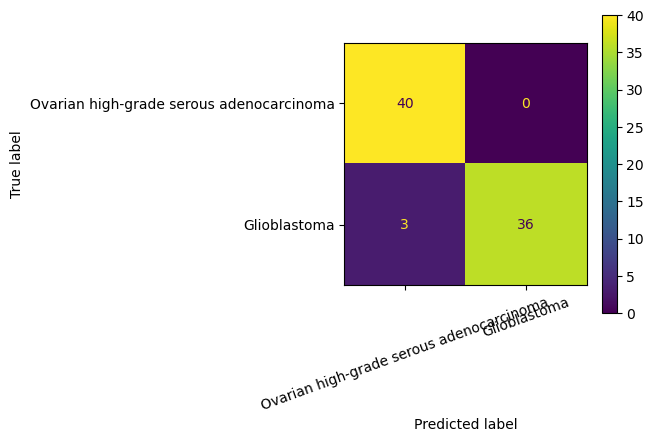

In [15]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=[GROUP_LABELS[GROUP_1], GROUP_LABELS[GROUP_2]],
)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Interpret the most informative bins

The logistic regression model assigns a coefficient to each feature.

- **Large positive coefficients** push predictions toward **glioblastoma**
- **Large negative coefficients** push predictions toward **ovarian high-grade serous adenocarcinoma**

A table of coefficients is useful, but it can feel abstract.

So in the next step we will also look at **simple histogram-style plots**
for a few informative bins. Those plots show how the bin values are distributed
in the two classes:

- `-1` = deletion
- `0` = no event
- `1` = duplication



In [16]:
# Fit coefficients from the logistic-regression part of the pipeline.
logreg = clf.named_steps["logisticregression"]

# Turn the coefficient vector into a pandas Series so that each value
# is labeled by its genome-bin feature name.
coefs = pd.Series(logreg.coef_[0], index=feature_cols)

# The bins with the largest positive coefficients support class 1
# (Glioblastoma in this notebook).
top_positive = coefs.sort_values(ascending=False).head(15).rename("coefficient").reset_index()
top_positive = top_positive.rename(columns={"index": "bin_id"})

# The bins with the most negative coefficients support class 0
# (Ovarian high-grade serous adenocarcinoma in this notebook).
top_negative = coefs.sort_values(ascending=True).head(15).rename("coefficient").reset_index()
top_negative = top_negative.rename(columns={"index": "bin_id"})

# Add a small helper column that is easier to read in class.
def format_bin_label(bin_id):
    # Example input: chr13_20000000_30000000
    chrom, start, end = bin_id.replace("chr", "").split("_")
    start_mb = int(start) / 1_000_000
    end_mb = int(end) / 1_000_000
    return f"chr{chrom}:{start_mb:.0f}-{end_mb:.0f} Mb"

top_positive["region"] = top_positive["bin_id"].map(format_bin_label)
top_negative["region"] = top_negative["bin_id"].map(format_bin_label)

print("Bins favoring Glioblastoma")
display(top_positive[["bin_id", "region", "coefficient"]])

print("Bins favoring Ovarian high-grade serous adenocarcinoma")
display(top_negative[["bin_id", "region", "coefficient"]])


Bins favoring Glioblastoma


,bin_id,region,coefficient
0,chr7_20000000_30000000,chr7:20-30 Mb,0.294065
1,chr7_10000000_20000000,chr7:10-20 Mb,0.284267
2,chr17_40000000_50000000,chr17:40-50 Mb,0.239952
3,chr18_50000000_60000000,chr18:50-60 Mb,0.237015
4,chr18_60000000_70000000,chr18:60-70 Mb,0.232806
5,chr2_230000000_240000000,chr2:230-240 Mb,0.230346
6,chr4_40000000_50000000,chr4:40-50 Mb,0.224275
7,chr4_20000000_30000000,chr4:20-30 Mb,0.221756
8,chr4_50000000_60000000,chr4:50-60 Mb,0.210069
9,chr1_210000000_220000000,chr1:210-220 Mb,0.209752


Bins favoring Ovarian high-grade serous adenocarcinoma


,bin_id,region,coefficient
0,chr1_130000000_140000000,chr1:130-140 Mb,-0.385896
1,chr8_130000000_140000000,chr8:130-140 Mb,-0.360529
2,chr1_120000000_130000000,chr1:120-130 Mb,-0.343838
3,chr20_60000000_64444167,chr20:60-64 Mb,-0.302062
4,chr8_120000000_130000000,chr8:120-130 Mb,-0.284357
5,chr12_10000000_20000000,chr12:10-20 Mb,-0.276021
6,chr22_30000000_40000000,chr22:30-40 Mb,-0.275836
7,chr20_30000000_40000000,chr20:30-40 Mb,-0.272212
8,chr4_190000000_190214555,chr4:190-190 Mb,-0.266059
9,chr8_140000000_145138636,chr8:140-145 Mb,-0.241559


## Plot a few informative bins and add Progenetix links

The coefficient table tells us **which bins matter most** to the model.

To make that result easier to understand, we now inspect a few of those bins directly.

For each selected bin, we draw a simple histogram-style plot of the sample values:

- `-1` means the sample has a deletion in that genomic bin
- `0` means there is no CNV event in that bin
- `1` means the sample has a duplication in that bin

If one class contains many more deletions or duplications in a bin than the other class,
that bin can become informative for classification.

At the end of the cell, we also print the official **Progenetix collation plot links**
for the two diagnostic groups. These are useful for connecting the machine-learning result
back to the broader group-level CNV landscape shown by Progenetix.


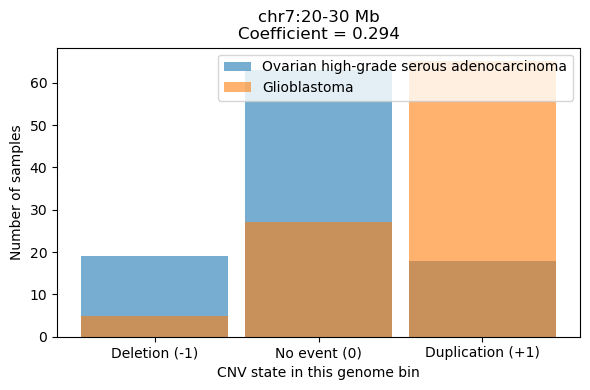

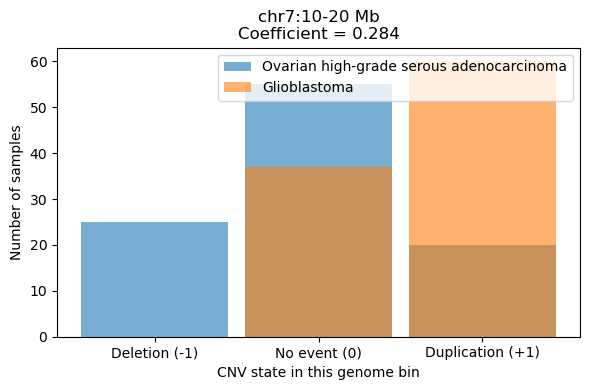

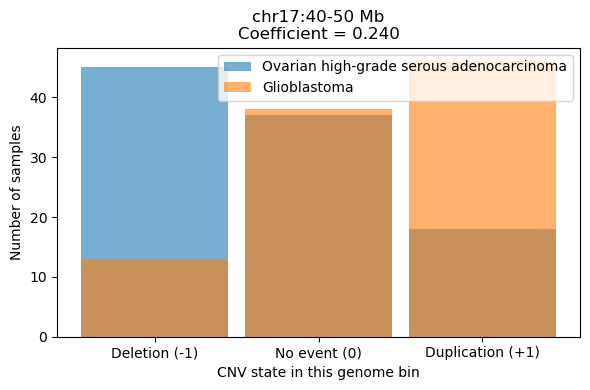

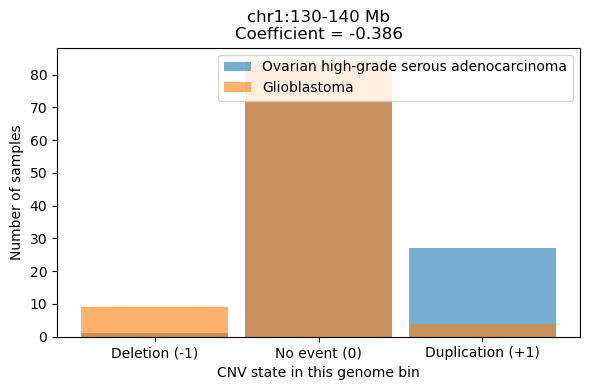

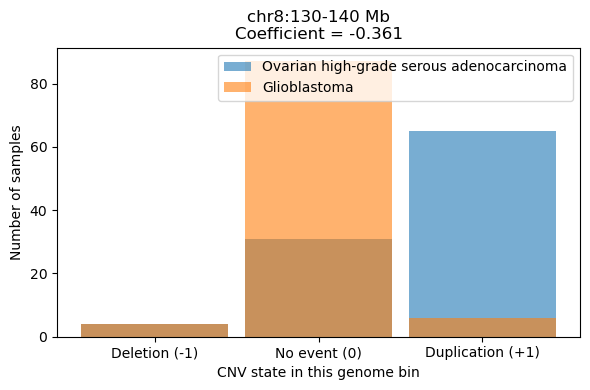

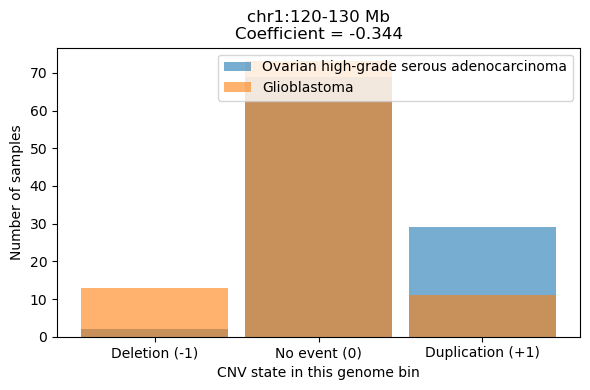

Official Progenetix group-level CNV frequency plots


,group_code,group_label,collationplot_link
0,NCIT:C105555,Ovarian high-grade serous adenocarcinoma,https://progenetix.org/services/collationplots...
1,NCIT:C3058,Glioblastoma,https://progenetix.org/services/collationplots...


In [17]:
# Add readable group labels for plotting.
plot_df = model_df.copy()
plot_df["group_label"] = plot_df["group_code"].map(GROUP_LABELS)

# Take a small set of highly informative bins:
# three bins favoring glioblastoma and three bins favoring ovarian HGSC.
bins_to_plot = (
    top_positive["bin_id"].head(3).tolist() +
    top_negative["bin_id"].head(3).tolist()
)

# Remove duplicates while preserving order.
bins_to_plot = list(dict.fromkeys(bins_to_plot))

for bin_id in bins_to_plot:
    plt.figure(figsize=(6, 4))

    # Plot one histogram per class on the same axes.
    for group_code in [GROUP_1, GROUP_2]:
        values = plot_df.loc[plot_df["group_code"] == group_code, bin_id]
        plt.hist(
            values,
            bins=[-1.5, -0.5, 0.5, 1.5],
            alpha=0.6,
            label=GROUP_LABELS[group_code],
            rwidth=0.9,
        )

    coef_value = coefs[bin_id]
    plt.xticks([-1, 0, 1], ["Deletion (-1)", "No event (0)", "Duplication (+1)"])
    plt.xlabel("CNV state in this genome bin")
    plt.ylabel("Number of samples")
    plt.title(f"{format_bin_label(bin_id)}\nCoefficient = {coef_value:.3f}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Progenetix links for the two groups used in this notebook.
progenetix_links = pd.DataFrame({
    "group_code": [GROUP_1, GROUP_2],
    "group_label": [GROUP_LABELS[GROUP_1], GROUP_LABELS[GROUP_2]],
    "collationplot_link": [
        f"https://progenetix.org/services/collationplots/?filters={GROUP_1}",
        f"https://progenetix.org/services/collationplots/?filters={GROUP_2}",
    ],
})

print("Official Progenetix group-level CNV frequency plots")
display(progenetix_links)


## Discussion and possible improvements

This teaching notebook is intentionally simple.

A few things could be improved in a more advanced analysis:

1. **Use more samples**  
   Small datasets are useful for illustration, but larger datasets usually give more stable estimates.

2. **Compare several train/test splits**  
   We already added repeated cross-validation, but a larger benchmark would still be better.

3. **Try different bin sizes**  
   Coarser bins are easier to explain; finer bins may capture more detail.

4. **Filter sample types more carefully**  
   For example, one could compare only primary tumor samples, or remove cell lines if needed.

5. **Compare multiple models**  
   Logistic regression is a good baseline, but random forests or linear SVMs are also common baselines.




### Exercise 1. Change the genome bin size
Change `BIN_SIZE` from `10_000_000` to `20_000_000` or `5_000_000`.

Questions:
- How many feature columns do you obtain?
- Does the model accuracy change?
- Does the list of top bins change?

### Exercise 2. Increase the number of samples
Increase `TARGET_SAMPLES_PER_CLASS` and rerun the notebook.

Questions:
- Does the cross-validation mean stay similar?
- Does the test accuracy become more or less stable?

### Exercise 3. Inspect one informative bin
Choose one bin from the interpretation table.

Tasks:
- write down whether that bin favors glioblastoma or ovarian HGSC
- inspect the histogram for that bin
- open the Progenetix collation plot link and describe whether the broad group-level pattern seems consistent with the model result

### Exercise 4. Try a different cancer pair
Replace one of the current groups with another CNV-rich cancer type.

Questions:
- Is the new classification easier or harder?
- Which genomic bins become important?
- Do the repeated cross-validation scores become higher or lower?
